# 01 - Exploration, cleaning, and the questions worth asking

**Week 1 deliverable.**

An online marketplace connects several thousand small sellers to customers spread across
Brazil. Leadership wants to grow it, and is worried that growth and customer experience
pull against each other: sign sellers up quickly and sales rise, but late deliveries and
poor products start driving customers away. Police the slow sellers and quality improves,
but the catalogue shrinks and growth stalls.

Right now that trade-off is being argued from instinct. Our job across these three
notebooks is to find out whether it is actually real, and if so, exactly where, because
"growth versus experience" is only a dilemma if the two are opposed *everywhere*. If they
are opposed in a few nameable places, that is not a dilemma, it is a work list.

**The five questions we set out to answer**

1. Is the marketplace already trading satisfaction for growth, or only at risk of it?
2. What actually drives a one-star review: the product, the seller, or the delivery?
3. If it is delivery, which part of the journey: the seller packing it, or the carrier
   moving it?
4. Which categories, regions, lanes and sellers carry disproportionate risk?
5. What would each available intervention cost in revenue, and buy in goodwill?

This notebook does none of the answering. It does the unglamorous part that decides
whether the answers are worth anything: understand the schema, find out where the data
lies to us, and define the population every later number is computed on.

**Dataset.** 99,441 orders placed between September 2016 and October 2018, spread across
nine relational tables, plus two more describing the marketing funnel that recruited the
sellers.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import plotly.io as pio

from src import analysis as A, viz as V, config as C

# Render every figure as a PNG *and* as interactive Plotly. The PNG is what
# makes these charts visible on GitHub, in nbviewer, and in any HTML or PDF
# export. Without it the cells below look blank to anyone who isn't running
# a live kernel.
pio.renderers.default = "png+plotly_mimetype"

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 40)

---
# 1. Getting oriented

Before touching anything we want to know how the tables connect and, more importantly,
what the *grain* of each one is, meaning what exactly one row represents. Getting the grain wrong
is how you end up double-counting revenue and never noticing.

In [2]:
import duckdb
con = duckdb.connect(str(C.DB_PATH))

for name in C.RAW_TABLES:
    n = con.execute(f'SELECT count(*) FROM raw_{name}').fetchone()[0]
    print(f'{name:24s} {n:>10,}')

orders                       99,441
order_items                 112,650
order_payments              103,886
order_reviews                99,224
customers                    99,441
sellers                       3,095
products                     32,951
category_translation             71
geolocation               1,000,163
mql                           8,000
closed_deals                    842


In [3]:
# Is order_id unique in orders, and repeated in items? The answer decides
# whether we can join these two tables without inflating anything.
grain = con.execute('''
  SELECT (SELECT count(*)                  FROM raw_orders)        AS order_rows,
         (SELECT count(DISTINCT order_id)  FROM raw_orders)        AS distinct_orders,
         (SELECT count(*)                  FROM raw_order_items)   AS item_rows,
         (SELECT count(DISTINCT order_id)  FROM raw_order_items)   AS orders_with_items,
         (SELECT count(*)                  FROM raw_order_reviews) AS review_rows,
         (SELECT count(DISTINCT order_id)  FROM raw_order_reviews) AS reviewed_orders,
         (SELECT count(*)                  FROM raw_customers)     AS customer_rows,
         (SELECT count(DISTINCT customer_unique_id) FROM raw_customers) AS real_people
''').df().T.rename(columns={0: 'count'})
grain

,count
order_rows,99441
distinct_orders,99441
item_rows,112650
orders_with_items,98666
review_rows,99224
reviewed_orders,98673
customer_rows,99441
real_people,96096


Three things fall out of that, and all three matter later.

**`order_items` has more rows than `orders`.** An order can contain several items, possibly
from several different sellers. So anything measured at order level has to be aggregated
first, and "number of orders" and "number of items" are simply different questions. This is
also the seed of one of the most useful findings in notebook 02: an order split across
sellers behaves very differently from one that isn't.

**`order_reviews` has more rows than it has distinct orders.** A few hundred orders were
surveyed twice. Join that naively and those orders get silently duplicated and counted
double, weighting the unhappiest customers, who are the most likely to be re-surveyed,
above everyone else.

**`customer_id` is not a person.** There are as many `customer_id` values as there are
orders, because a fresh one is minted per order; `customer_unique_id` is the actual human.
We nearly missed this, and it would have made the repeat-purchase rate come out at exactly
zero, which, as section 4 shows, is a number the entire valuation argument rests on.

---
# 2. Data quality

We would rather find the problems now than have one surface halfway through a
presentation. The ingest step walks every table looking for three things: missing values,
internal contradictions, and events that are physically impossible. Each finding is
recorded next to the decision we made about it, so the judgement calls are reviewable
instead of buried somewhere in the code.

In [4]:
audit = pd.read_csv(C.TABLE_DIR / 'data_quality_audit.csv')
audit.style.format({'rows': '{:,.0f}', 'share': '{:.2%}'}, na_rep='n/a').hide(axis='index')

area,finding,rows,share,treatment
orders,order_approved_at missing,160,0.16%,Retained; excluded only from metrics that require the timestamp
orders,order_delivered_carrier_date missing,"1,783",1.79%,Retained; excluded only from metrics that require the timestamp
orders,order_delivered_customer_date missing,"2,965",2.98%,Retained; excluded only from metrics that require the timestamp
orders,order_status not 'delivered',"2,963",2.98%,Excluded from the satisfaction model; kept for the funnel view
orders,status='delivered' but no delivery date,8,0.01%,Dropped from delivery analysis: the outcome date is unknowable
orders,lifecycle timestamps out of order,"1,382",1.39%,Order kept; the impossible stage duration is nulled so it cannot distort stage averages
products,product_category_name missing,610,1.85%,Mapped to 'unknown' so the orders are not silently lost in joins
products,categories missing English translation,2,n/a,Fall back to the Portuguese name rather than dropping the row
reviews,orders with more than one review,547,n/a,Kept the earliest review per order
reviews,review with no written comment,"58,247",58.70%,Text analysis runs on the commented subset only; stated as a caveat


In [5]:
# Pull out the specific figures the discussion below leans on, rather than
# quoting numbers that could silently go stale.
def finding(substr):
    row = audit[audit.finding.str.contains(substr, case=False, regex=False)].iloc[0]
    return int(row['rows']), float(row['share']) if pd.notna(row['share']) else None

no_delivery_date, no_delivery_share = finding('order_delivered_customer_date missing')
impossible,       impossible_share  = finding('lifecycle timestamps out of order')
contradiction,    _                 = finding("status='delivered' but no delivery date")
dup_reviews,      _                 = finding('more than one review')
no_comment,       no_comment_share  = finding('no written comment')
dead_deals,       dead_deal_share   = finding('seller never transacted')

print(f'No delivery date recorded : {no_delivery_date:,}  ({no_delivery_share:.1%} of orders)')
print(f'  ...of which contradict  : {contradiction:,}  (status says delivered anyway)')
print(f'Impossible stage ordering : {impossible:,}  ({impossible_share:.1%})')
print(f'Orders reviewed twice     : {dup_reviews:,}')
print(f'Reviews with no comment   : {no_comment:,}  ({no_comment_share:.0%})')
print(f'Closed deals, never traded: {dead_deals:,}  ({dead_deal_share:.0%})')

No delivery date recorded : 2,965  (3.0% of orders)
  ...of which contradict  : 8  (status says delivered anyway)
Impossible stage ordering : 1,382  (1.4%)
Orders reviewed twice     : 547
Reviews with no comment   : 58,247  (59%)
Closed deals, never traded: 462  (55%)


Two of those needed a real decision rather than a default.

**Impossible timestamps: null the stage, keep the order.** There are 1,382 orders whose
lifecycle timestamps run out of order: delivered before dispatched, that kind of thing.
These are not real events, they are recording faults, most likely batch jobs writing
timestamps after the fact. We could drop the orders, but the purchase-to-delivery duration
is still perfectly valid for them; it is only the individual stage that is nonsense. So we
null the offending stage duration and keep everything else. That is 1.4% of orders losing
*one field*, rather than 1.4% of orders being deleted.

**Lateness must be unknown, not false.** This is the one most likely to produce a
confidently wrong answer. When an order has no delivery date, "was it late?" has no
answer, but the tempting default is `False`. Take that default and every undelivered
order silently counts as on-time, and the on-time rate comes out better than reality. We
keep it as null throughout, and every rate below is computed on the orders where the
question actually has an answer.

The remaining findings are less dangerous but worth stating: duplicate reviews are resolved
by keeping the earliest one per order; missing product categories are mapped to `unknown`
rather than dropped, so those orders do not vanish from a join; and 59% of closed marketing
deals belong to sellers who never transacted, which we return to in section 5.

---
# 3. Defining the population once

Every satisfaction number from here to the end of notebook 03 is computed on the same set
of orders: **delivered, and carrying a review**. It is defined in exactly one place,
`A.analysis_base`, so that no two charts anywhere in this project can quietly disagree
about their denominator. It is a small discipline and it saves a lot of embarrassment.

We also trim the window to January 2017 - August 2018. The months on either side hold only
a handful of orders, and they make every trend line look dramatic for no reason at all.

While we are fixing vocabulary, here is the decomposition of the delivery journey that the
rest of the project is built on. It matters because it assigns each delay to somebody:

| Stage | From | To | Whose delay it is |
|---|---|---|---|
| Approval | purchase | payment cleared | the payment system |
| Handling | payment cleared | carrier collects | **the seller** |
| Transit | carrier collects | customer receives | **the carrier** |

Plus `delay_days`, which is the delivery date minus the *promised* date. Positive means
late. That is the number the customer actually experiences: they have no idea how long
the order "should" have taken, only what they were told at checkout.

In [6]:
base = A.analysis_base(A.load_facts())

print(f'Orders in the raw data      : {len(A.load_facts()):,}')
print(f'Delivered, reviewed, in-window: {len(base):,}')
print()

dist = base.review_score.value_counts().sort_index()
print((dist / dist.sum()).round(3).to_string())
print(f'\nMean score      : {base.review_score.mean():.3f}')
print(f'1-2 star share  : {base.is_bad_review.mean():.2%}')

Orders in the raw data      : 99,441
Delivered, reviewed, in-window: 95,560

review_score
1.0    0.097
2.0    0.031
3.0    0.082
4.0    0.197
5.0    0.592

Mean score      : 4.157
1-2 star share  : 12.79%


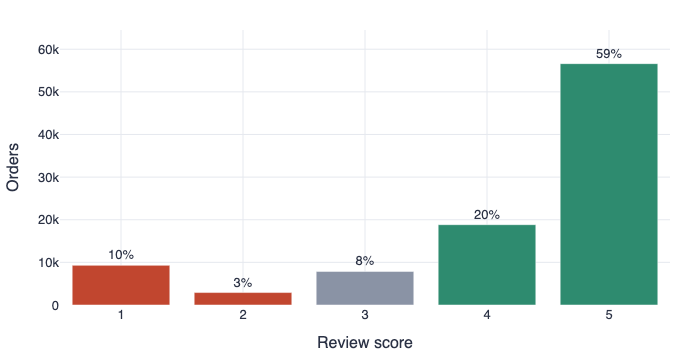

In [7]:
V.fig_score_distribution(base)

This shape changed how we approached everything that follows.

**59% of reviews are five stars. 10% are one star. The whole 2-to-3 band together is 11%.**
The distribution is not a bell, it is two piles at opposite ends of the scale with a dip
between them. So the mean of 4.16 describes a region where relatively few actual reviews
fall; it is close to the average of a crowd standing at two ends of a room, and it will
move sluggishly no matter what happens to the people in it.

That makes predicting or tracking the *average score* close to useless operationally. What
matters is whether an order produces a **detractor**: someone leaving one or two stars. It
is binary, it is well defined, and it maps onto something a business can actually act on.
Every model, metric and scenario from here on treats detractors as the outcome.

In [8]:
# The single most important early check: does lateness matter at all?
check = base.groupby('is_late').agg(
    orders=('order_id', 'size'),
    avg_score=('review_score', 'mean'),
    one_star_rate=('review_score', lambda s: (s == 1).mean()),
    detractor_rate=('is_bad_review', 'mean'),
).round(3)
check.index = ['On time', 'Late']
check

,orders,avg_score,one_star_rate,detractor_rate
On time,87902,4.295,0.066,0.092
Late,7658,2.568,0.461,0.540


There it is, and it is not subtle.

On-time orders average **4.30 stars**. Late ones average **2.57**. That is not a nudge, it
is a collapse of 1.7 stars from a single binary. 46% of late orders draw a *one-star*
review, against 7% of on-time ones. Nothing else we tested in this dataset comes close to
that effect size.

So question 2 already has a provisional answer: it is the delivery. Notebook 02 takes that
apart properly: whether the damage is gradual or a cliff, and whose delay it actually
is.

---
# 4. The metric the rest of the project runs on

There is a problem with ranking segments by how bad they are. Maranhão has a terrible
average score, but there are only a few hundred orders in it. São Paulo looks healthy but
is 42% of the marketplace. Which one should be fixed first?

Ranking by badness picks Maranhão. Ranking by size picks São Paulo. Neither is the right
answer, because the thing we actually care about, total goodwill destroyed, is the
product of the two. So we define **Satisfaction-at-Risk**:

```
excess detractors = orders × (segment bad-rate - marketplace bad-rate)
```

In plain English: **how many one- and two-star reviews would disappear if this segment
merely behaved like the marketplace average?** Positive means the segment is destroying
more goodwill than its size warrants; negative means it is doing better than its share.

To turn that into money we multiply by the segment's average order value. That step is a
judgement call, and it rests entirely on the following number.

In [9]:
facts = A.load_facts()
repeat_rate = facts.groupby('customer_unique_id').size().gt(1).mean()
aov = base.item_total.sum() / len(base)

print(f'Customers who ever order twice : {repeat_rate:.1%}')
print(f'Average order value            : R$ {aov:,.2f}')
print(f'Marketplace detractor rate     : {base.is_bad_review.mean():.2%}')

Customers who ever order twice : 3.1%
Average order value            : R$ 136.76
Marketplace detractor rate     : 12.79%


In [10]:
# SAR in action, on customer state. `A.satisfaction_at_risk` attaches the
# columns to any grouped summary that already has orders / bad_rate / gmv.
baseline = float(base.is_bad_review.mean())
state = A.state_view(base, baseline)

state.nlargest(8, 'gmv_exposure')[
    ['customer_state', 'orders', 'avg_score', 'bad_rate',
     'excess_detractors', 'gmv_exposure']
].round(3)

,customer_state,orders,avg_score,bad_rate,excess_detractors,gmv_exposure
18,RJ,12172,3.964,0.184,677.726,96132.819
4,BA,3226,3.930,0.170,137.534,20887.796
5,CE,1267,3.935,0.174,58.005,9940.238
13,PA,929,3.904,0.182,50.221,9183.485
9,MA,709,3.831,0.200,51.349,8387.095
1,AL,393,3.858,0.211,32.752,6447.023
15,PE,1573,4.081,0.148,31.881,5045.932
24,SE,331,3.900,0.190,20.679,3460.451


Only **3.1%** of customers ever place a second order.

In a marketplace with essentially no repeat purchase, an unhappy customer is not somebody
to win back with a voucher. They are already gone, and whatever was spent acquiring them
bought exactly one order. Valuing a detractor at one average order value is therefore a
defensible *floor*: it ignores word of mouth, and it ignores all the orders that customer
now never places. The true cost is higher. We would rather under-claim and have the number
survive scrutiny.

Look at what the metric does to the ranking. Rio de Janeiro surfaces at or near the top,
which no league table sorted by average score would ever do: it is mid-table on score, but
it is the second-largest market in the country and runs several times São Paulo's late
rate. Volume times a bad rate is where the real damage lives, and Rio has both.

This one formula is what makes notebook 02's segment work actionable rather than merely
descriptive.

---
# 5. Where the sellers came from

Two of the eleven tables describe the marketing funnel: leads that were qualified, and
deals that closed. They are easy to ignore, because they sit off to the side of the order
data. But the brief is about *growing the marketplace*, and growth means recruiting
sellers, so the question of whether some acquisition channels deliver better sellers than
others is squarely on topic.

In [11]:
mkt = pd.read_csv(C.TABLE_DIR / 'marketing.csv')
origin = mkt[mkt.dimension == 'Lead origin'].dropna(subset=['segment'])

origin[['segment', 'leads_won', 'activation_rate', 'avg_orders',
        'avg_score', 'avg_late_rate', 'gmv']].round(3)

,segment,leads_won,activation_rate,avg_orders,avg_score,avg_late_rate,gmv
34,unknown,179,0.447,15.550,4.349,0.082,209913.09
35,organic_search,271,0.410,10.477,4.413,0.057,203372.61
36,paid_search,195,0.508,12.172,4.341,0.071,149895.23
37,social,75,0.413,12.452,4.418,0.077,43580.41
38,direct_traffic,56,0.554,6.065,4.313,0.059,21892.90
39,referral,24,0.375,7.444,4.468,0.028,16608.24
40,email,15,0.400,3.500,4.622,0.000,8335.49
41,other,4,0.500,43.000,4.131,0.146,6776.75
43,display,6,0.333,3.500,4.250,0.083,923.00
44,other_publicities,3,0.000,NaN,NaN,NaN,0.00


The headline is the **activation rate**: across every channel, only a minority of closed
deals ever produce a single order. 462 of the 842 sellers we signed (55%) never
transacted at all. Any growth plan built on "deals closed" is measuring something roughly
twice as large as what actually arrives.

Among the channels that do activate, the differences are real but modest, and the sample
sizes get thin quickly. `paid_search` and `direct_traffic` activate best (51% and 55%);
`organic_search` brings the largest number of winners and their sellers rate slightly
higher. Nothing here suggests one channel is recruiting systematically bad sellers, which
is genuinely useful to know: it means the satisfaction problem is *not* an acquisition
problem, and the fix does not lie upstream in marketing.

**The caveat is load-bearing and we are not burying it.** This table is scoped to sellers we
could match into the order data. The 55% who never transacted have no orders, no reviews and
no GMV, so they cannot be scored on quality; they are counted in `leads_won` and in the
activation rate, and are absent from every other column. That asymmetry is why we read the
channel-quality differences as weak signal, and why we would not reallocate a marketing
budget on this table alone.

---
# 6. What we carry into notebook 02

The groundwork is done and it has already narrowed the problem considerably.

- The analysis population is **95,560 orders**: delivered, reviewed, and inside the
  reporting window, defined once and reused everywhere.
- The outcome is **binary detractors**, not mean score, because the score distribution is
  hollow in the middle.
- Lateness is the dominant candidate cause: **4.30 stars on time against 2.57 late**.
- Segments will be ranked by **Satisfaction-at-Risk**, which weighs severity by size, and
  priced at one average order value per detractor on the strength of a **3.1%** repeat rate.
- Acquisition is *not* where the problem lives, so notebook 02 can concentrate entirely on
  fulfilment.

Notebook 02 takes the lateness finding apart: whether the damage accumulates gradually or
falls off a cliff, whether the delay belongs to the seller or the carrier, and which
categories, regions and shipping lanes carry it.